# Use Python 3.11

Pytorch is run on GPU


In [1]:
import warnings
import torch
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu129
CUDA available: True
GPU: NVIDIA GeForce RTX 5070


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [3]:
df = pd.read_csv('data/Processed_S&P.csv')
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.head()

,Date,Close,Volume,mom,mom1,mom2,mom3,ROC_5,ROC_10,ROC_15,...,NZD,silver-F,RUSSELL-F,S&P-F,CHF,Dollar index-F,Dollar index,wheat-F,XAG,XAU
0,2009-12-31,1115.099976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.03,0.26,-1.08,-1.00,-0.11,-0.08,-0.06,-0.48,0.30,0.39
1,2010-01-04,1132.989990,0.921723,0.016043,NaN,NaN,NaN,NaN,NaN,NaN,...,1.52,3.26,1.61,1.62,-0.57,-0.59,-0.42,3.12,3.91,2.10
2,2010-01-05,1136.520020,-0.375903,0.003116,0.016043,NaN,NaN,NaN,NaN,NaN,...,-0.07,1.96,-0.20,0.31,0.43,0.03,0.12,-0.90,1.42,-0.12
3,2010-01-06,1137.140015,0.996234,0.000546,0.003116,0.016043,NaN,NaN,NaN,NaN,...,0.56,2.15,-0.02,0.07,-0.56,-0.24,-0.17,2.62,2.25,1.77
4,2010-01-07,1141.689941,0.059932,0.004001,0.000546,0.003116,0.016043,NaN,NaN,NaN,...,-0.72,0.94,0.50,0.40,0.58,0.58,0.54,-1.85,0.22,-0.58


In [4]:
# for regression - find returns
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df["target_return"] = df["log_return"].shift(-1)

# for classification - find direction
df["target_direction"] = (df["target_return"] > 0).astype(int)


In [5]:
# to capture short-term price behavior i am making those 3 new features.
# return_1 and return_5 and return_10 for capturing small trends
df["return_1"] = df["Close"].pct_change()
df["return_5"] = df["Close"].pct_change(5)
df["return_10"] = df["Close"].pct_change(10)

for lag in [1,2,3,5,10]:
    df[f"log_return_lag{lag}"] = df["log_return"].shift(lag)

df["ema_gap_10"] = df["Close"] - df["EMA_10"]
df["ema_gap_20"] = df["Close"] - df["EMA_20"]
df["ema_gap_50"] = df["Close"] - df["EMA_50"]
df["ema_gap_200"] = df["Close"] - df["EMA_200"]

df["volatility_10"] = df["return_1"].rolling(10).std()
df["volatility_20"] = df["return_1"].rolling(20).std()

In [6]:
df = df.dropna(how="any")


df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

train = df[df.index < "2017"]
test = df[df.index >= "2017"]

In [7]:
df.head()

,Close,Volume,mom,mom1,mom2,mom3,ROC_5,ROC_10,ROC_15,ROC_20,...,log_return_lag2,log_return_lag3,log_return_lag5,log_return_lag10,ema_gap_10,ema_gap_20,ema_gap_50,ema_gap_200,volatility_10,volatility_20
Date,,,,,,,,,,,,,,,,,,,,,
2010-10-19,1165.900024,0.258440,-0.015877,0.007244,0.002027,-0.003641,-0.330834,0.443681,1.585787,2.291670,...,0.002025,-0.003648,0.003811,0.020647,-2.403547,9.453392,33.630729,44.397486,0.006878,0.008984
2010-10-20,1178.170044,-0.102184,0.010524,-0.015877,0.007244,0.002027,0.005948,1.569012,2.921219,3.869416,...,0.007218,0.002025,0.007096,-0.000672,8.072568,19.654515,44.100720,56.103650,0.007551,0.009099
2010-10-21,1180.260010,-0.080036,0.001774,0.010524,-0.015877,0.007244,0.549488,1.916995,3.422718,4.927861,...,-0.016005,0.007218,-0.003648,-0.001648,8.314801,19.673578,44.379286,57.614575,0.007465,0.008774
2010-10-26,1185.640015,-0.004193,0.000017,0.002147,0.002389,0.001774,1.693112,1.356677,2.144305,3.305748,...,0.002386,0.001772,-0.016005,0.003811,7.815332,18.756815,44.225255,61.157960,0.007288,0.007373
2010-10-27,1182.449951,0.031399,-0.002691,0.000017,0.002147,0.002389,0.363267,0.369236,1.937979,3.295098,...,0.002145,0.002386,0.010469,0.007096,3.784310,14.084204,39.425968,57.391101,0.007086,0.007376


In [8]:
train

,Close,Volume,mom,mom1,mom2,mom3,ROC_5,ROC_10,ROC_15,ROC_20,...,log_return_lag2,log_return_lag3,log_return_lag5,log_return_lag10,ema_gap_10,ema_gap_20,ema_gap_50,ema_gap_200,volatility_10,volatility_20
Date,,,,,,,,,,,,,,,,,,,,,
2010-10-19,1165.900024,0.258440,-0.015877,0.007244,0.002027,-0.003641,-0.330834,0.443681,1.585787,2.291670,...,0.002025,-0.003648,0.003811,0.020647,-2.403547,9.453392,33.630729,44.397486,0.006878,0.008984
2010-10-20,1178.170044,-0.102184,0.010524,-0.015877,0.007244,0.002027,0.005948,1.569012,2.921219,3.869416,...,0.007218,0.002025,0.007096,-0.000672,8.072568,19.654515,44.100720,56.103650,0.007551,0.009099
2010-10-21,1180.260010,-0.080036,0.001774,0.010524,-0.015877,0.007244,0.549488,1.916995,3.422718,4.927861,...,-0.016005,0.007218,-0.003648,-0.001648,8.314801,19.673578,44.379286,57.614575,0.007465,0.008774
2010-10-26,1185.640015,-0.004193,0.000017,0.002147,0.002389,0.001774,1.693112,1.356677,2.144305,3.305748,...,0.002386,0.001772,-0.016005,0.003811,7.815332,18.756815,44.225255,61.157960,0.007288,0.007373
2010-10-27,1182.449951,0.031399,-0.002691,0.000017,0.002147,0.002389,0.363267,0.369236,1.937979,3.295098,...,0.002145,0.002386,0.010469,0.007096,3.784310,14.084204,39.425968,57.391101,0.007086,0.007376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-20,2270.760010,0.015519,0.003638,0.001975,-0.001751,0.003883,-0.042257,2.645748,2.998199,3.301826,...,-0.001752,0.003876,0.006518,0.003405,17.760190,37.932381,72.879114,136.939379,0.005670,0.004702
2016-12-21,2265.179932,-0.135368,-0.002457,0.003638,0.001975,-0.001751,0.528115,1.063191,3.018445,2.825315,...,0.001973,-0.001752,-0.008150,0.013077,9.965546,29.271132,64.659858,130.052243,0.004470,0.004787
2016-12-22,2260.959961,0.008446,-0.001863,-0.002457,0.003638,0.001975,-0.047306,0.657559,3.189289,2.550890,...,0.003631,0.001973,0.003876,0.002157,4.700925,22.665336,58.069695,124.580210,0.004541,0.004842


In [9]:
test

,Close,Volume,mom,mom1,mom2,mom3,ROC_5,ROC_10,ROC_15,ROC_20,...,log_return_lag2,log_return_lag3,log_return_lag5,log_return_lag10,ema_gap_10,ema_gap_20,ema_gap_50,ema_gap_200,volatility_10,volatility_20
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-03,2257.830078,0.411708,0.008487,-0.004637,-0.000293,-0.008357,-0.263274,-0.010628,-0.075235,3.005549,...,-0.000293,-0.008392,0.001251,-0.001752,3.830925,12.529876,43.956441,114.562646,0.004675,0.005325
2017-01-04,2270.750000,-0.001496,0.005722,0.008487,-0.004637,-0.000293,0.082425,0.363309,0.611001,2.995407,...,-0.004648,-0.000293,0.002246,0.001973,13.705238,23.026008,54.645918,126.214085,0.004991,0.005321
2017-01-05,2269.000000,-0.000815,-0.000771,0.005722,0.008487,-0.004637,0.848034,-0.077508,-0.119732,2.566190,...,0.008451,-0.004648,-0.008392,0.003631,9.781559,19.249722,50.821568,123.225636,0.004863,0.005324
2017-01-06,2276.979980,-0.112161,0.003517,-0.000771,0.005722,0.008487,1.232404,0.520932,1.051798,1.589662,...,0.005706,0.008451,-0.000293,-0.002460,14.532168,24.636397,56.495605,129.900088,0.004904,0.004575
2017-01-09,2268.899902,-0.036612,-0.003549,0.003517,-0.000771,0.005722,1.343104,0.351176,0.303704,1.011044,...,-0.000771,0.005706,-0.004648,-0.001865,5.278983,14.979526,46.516879,120.607870,0.005023,0.004663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-08-09,2474.020020,-0.010937,-0.000364,-0.002414,0.001647,0.001889,-0.143287,-0.153766,0.007678,1.259389,...,0.001646,0.001887,0.000493,0.000283,-0.161229,6.406137,27.648463,127.449780,0.001709,0.002092
2017-08-10,2438.209961,0.094620,-0.014474,-0.000364,-0.002414,0.001647,-1.373291,-1.503178,-1.424730,-0.393006,...,-0.002417,0.001646,-0.002186,-0.000973,-29.431054,-26.603549,-7.841533,90.727883,0.004859,0.003949
2017-08-16,2468.110107,0.013920,0.001420,-0.000499,0.010044,0.001276,-0.238879,-0.381824,-0.392278,-0.231219,...,0.009994,0.001275,-0.000364,0.000493,3.675006,4.577273,19.942531,116.213406,0.006055,0.004295


# Regressors (RandomForest, Adaboost, Gradient boosting) to predict next day return

In [10]:
features = [
    "return_1", "return_5", "return_10",
    "log_return_lag1", "log_return_lag2", "log_return_lag3",
    "log_return_lag5", "log_return_lag10",
    "ema_gap_10", "ema_gap_20", "ema_gap_50", "ema_gap_200",
    "volatility_10", "volatility_20"
]

X_train = train[features]
y_train = train["target_return"]

X_test = test[features]
y_test = test["target_return"]

In [11]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor

# sort by day
N = len(y_train)
alpha = 0.003
t = np.arange(N)

# i decided to add weights. so, most recent data has more weight than previous
base_w = np.exp(alpha * t)          # your time weights
amp_w  = 1 + 5 * np.abs(y_train)    # extra weight for big moves
sample_weight = base_w * amp_w


sample_weight = sample_weight / sample_weight.mean()

tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15],
    "min_samples_leaf": [1, 2, 3, 5]
}

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=tscv,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train, sample_weight=sample_weight)

best_rf = rf_search.best_estimator_
rf_pred = best_rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_dir_acc = (np.sign(rf_pred) == np.sign(y_test)).mean()

print("RF best params:", rf_search.best_params_)
print("RF RMSE:", rf_rmse)
print("RF Direction Acc:", rf_dir_acc)


# ADA BOOST
ada = AdaBoostRegressor(random_state=42)

ada_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.005, 0.01, 0.02, 0.05, 0.1],
    "loss": ["linear", "square", "exponential"]
}

ada_search = RandomizedSearchCV(
    ada,
    param_distributions=ada_param_dist,
    n_iter=15,
    cv=tscv,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

ada_search.fit(X_train, y_train, sample_weight=sample_weight)

best_ada = ada_search.best_estimator_
ada_pred = best_ada.predict(X_test)

ada_rmse = np.sqrt(mean_squared_error(y_test, ada_pred))
ada_dir_acc = (np.sign(ada_pred) == np.sign(y_test)).mean()

print("AdaBoost best params:", ada_search.best_params_)
print("AdaBoost RMSE:", ada_rmse)
print("AdaBoost Direction Acc:", ada_dir_acc)

# GRADIENT BOOST
gbr = GradientBoostingRegressor(random_state=42)

gbr_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.005, 0.01, 0.02, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.6, 0.8, 1.0],
    "min_samples_leaf": [1, 3, 5],
}

gbr_search = RandomizedSearchCV(
    gbr,
    param_distributions=gbr_param_dist,
    n_iter=20,
    cv=tscv,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

gbr_search.fit(X_train, y_train, sample_weight=sample_weight)

best_gbr = gbr_search.best_estimator_
gbr_pred = best_gbr.predict(X_test)

gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))
gbr_dir_acc = (np.sign(gbr_pred) == np.sign(y_test)).mean()

print("GradientBoost best params:", gbr_search.best_params_)
print("GradientBoost RMSE:", gbr_rmse)
print("GradientBoost Direction Acc:", gbr_dir_acc)

RF best params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 5}
RF RMSE: 0.005399078524744366
RF Direction Acc: 0.53
AdaBoost best params: {'n_estimators': 200, 'loss': 'linear', 'learning_rate': 0.01}
AdaBoost RMSE: 0.004901083844217549
AdaBoost Direction Acc: 0.54
GradientBoost best params: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.005}
GradientBoost RMSE: 0.005079857201359945
GradientBoost Direction Acc: 0.5


In [12]:
# Baseline 1: always predict 0 return
baseline_pred = np.zeros_like(y_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

# Baseline 2: predict yesterday's return
y_test_shift = y_test.shift(1).dropna()
model_aligned = y_test.iloc[1:]
baseline2_rmse = np.sqrt(mean_squared_error(model_aligned, y_test_shift))

print("Baseline 1 (always 0) RMSE:", baseline_rmse)
print("Baseline 2 (yesterday's return) RMSE:", baseline2_rmse)


Baseline 1 (always 0) RMSE: 0.004903430933519664
Baseline 2 (yesterday's return) RMSE: 0.007054328765179602


## Why Do Models Match the Baseline?

The fact that our best model (AdaBoost, RMSE = 0.0049) essentially equals the trivial baseline of predicting zero (RMSE = 0.0049) is not a failure of implementation—it's **theoretically expected**.

**Efficient Market Hypothesis (EMH)**: All public information (technical indicators, macro variables, historical prices) is already incorporated into current prices. Since our features are all derived from public data, any predictive signal has already been arbitraged away by market participants.

**Signal-to-Noise Ratio**: Daily S&P 500 returns have:
- Mean (μ) ≈ 0.04% (the signal we're trying to predict)
- Standard deviation (σ) ≈ 1.0% (the noise)
- Ratio: ~25:1 noise-to-signal

Predicting "zero" is actually the rational strategy when signal is dwarfed by noise. The model has learned this implicitly.

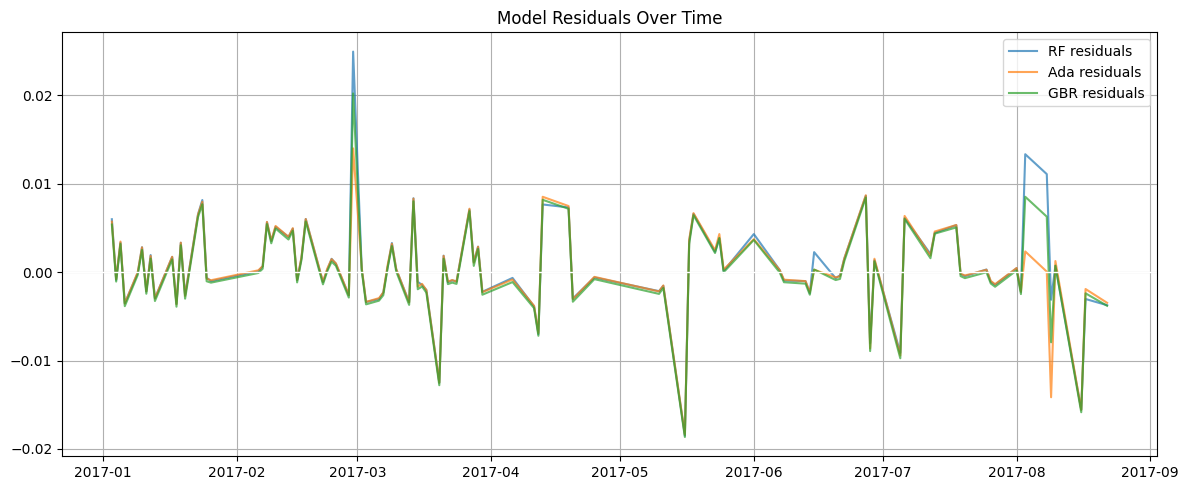

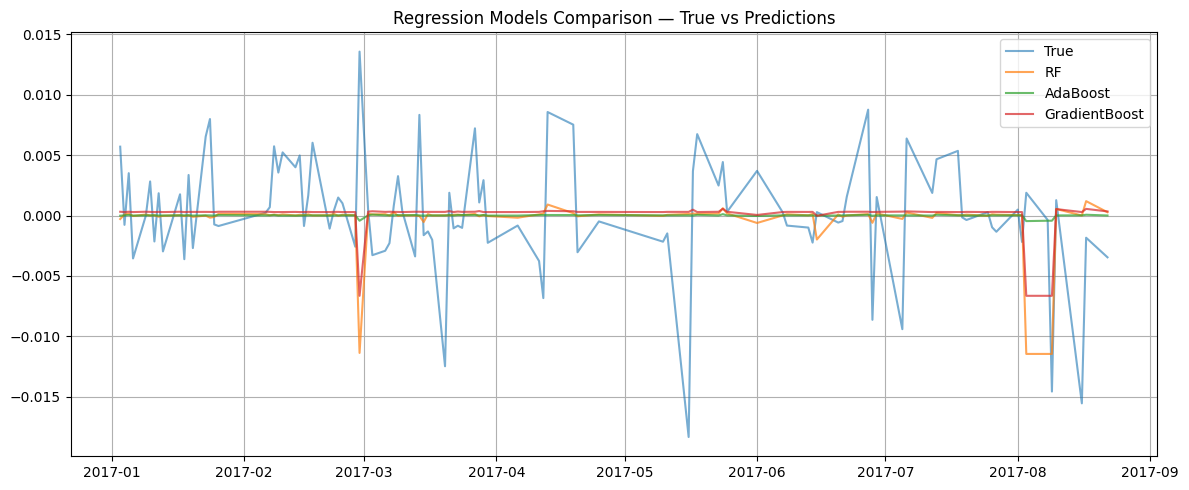

In [13]:
rf_series  = pd.Series(rf_pred,  index=y_test.index, name="RF")
ada_series = pd.Series(ada_pred, index=y_test.index, name="AdaBoost")
gbr_series = pd.Series(gbr_pred, index=y_test.index, name="GradientBoost")
rf_resid  = y_test - rf_series
ada_resid = y_test - ada_series
gbr_resid = y_test - gbr_series

plt.figure(figsize=(12,5))
plt.plot(y_test.index, rf_resid,  label="RF residuals",  alpha=0.7)
plt.plot(y_test.index, ada_resid, label="Ada residuals", alpha=0.7)
plt.plot(y_test.index, gbr_resid, label="GBR residuals", alpha=0.7)
plt.axhline(0, color="white", linewidth=1)
plt.title("Model Residuals Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test,        label="True",         alpha=0.6)
plt.plot(y_test.index, rf_series,     label="RF",           alpha=0.7)
plt.plot(y_test.index, ada_series,    label="AdaBoost",     alpha=0.7)
plt.plot(y_test.index, gbr_series,    label="GradientBoost",alpha=0.7)

plt.title("Regression Models Comparison — True vs Predictions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


now lets find direction using classification

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier


y_train_cls = train["target_direction"]
y_test_cls = test["target_direction"]

alpha = 0.003
N_train = len(y_train_cls)
t = np.arange(N_train)

time_weights = np.exp(alpha * t)
time_weights = time_weights / time_weights.mean()
sample_weight_cls = time_weights

tscv = TimeSeriesSplit(n_splits=5)

features = [
    "return_1", "return_5", "return_10",
    "log_return_lag1", "log_return_lag2", "log_return_lag3",
    "log_return_lag5", "log_return_lag10",
    "ema_gap_10", "ema_gap_20", "ema_gap_50", "ema_gap_200",
    "volatility_10", "volatility_20", "Oil", "Gold", "Dollar index"
]

t = np.arange(len(y_train_cls))

time_weights = np.exp(alpha * t)
time_weights = time_weights / time_weights.mean()
sample_weight_cls = time_weights

tscv = TimeSeriesSplit(n_splits=5)


rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42,
)

rf_param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 3, 5, 7, 9],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    rf_clf,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
)

rf_search.fit(X_train, y_train_cls)

best_rf = rf_search.best_estimator_
rf_pred = best_rf.predict(X_test)
rf_proba = best_rf.predict_proba(X_test)[:, 1]

print("\n=== RandomForestClassifier ===")
print("Best params:", rf_search.best_params_)
print("Accuracy:", accuracy_score(y_test_cls, rf_pred))
print("Confusion matrix:\n", confusion_matrix(y_test_cls, rf_pred))
print("Classification report:\n", classification_report(y_test_cls, rf_pred))


ada_clf = AdaBoostClassifier(random_state=42)

ada_param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
}

ada_search = RandomizedSearchCV(
    ada_clf,
    param_distributions=ada_param_dist,
    n_iter=15,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
)

ada_search.fit(X_train, y_train_cls)

best_ada = ada_search.best_estimator_
ada_pred = best_ada.predict(X_test)
ada_proba = best_ada.predict_proba(X_test)[:, 1]

print("\n=== AdaBoostClassifier ===")
print("Best params:", ada_search.best_params_)
print("Accuracy:", accuracy_score(y_test_cls, ada_pred))
print("Confusion matrix:\n", confusion_matrix(y_test_cls, ada_pred))
print("Classification report:\n", classification_report(y_test_cls, ada_pred))


gbr_clf = GradientBoostingClassifier(random_state=42)

gbr_param_dist = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.6, 0.8, 1.0],
    "min_samples_leaf": [1, 3, 5],
}

gbr_search = RandomizedSearchCV(
    gbr_clf,
    param_distributions=gbr_param_dist,
    n_iter=20,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
)

gbr_search.fit(X_train, y_train_cls)

best_gbr = gbr_search.best_estimator_
gbr_pred = best_gbr.predict(X_test)
gbr_proba = best_gbr.predict_proba(X_test)[:, 1]

print("\n=== GradientBoostingClassifier ===")
print("Best params:", gbr_search.best_params_)
print("Accuracy:", accuracy_score(y_test_cls, gbr_pred))
print("Confusion matrix:\n", confusion_matrix(y_test_cls, gbr_pred))
print("Classification report:\n", classification_report(y_test_cls, gbr_pred))


=== RandomForestClassifier ===
Best params: {'n_estimators': 200, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_depth': 5}
Accuracy: 0.5
Confusion matrix:
 [[27 22]
 [28 23]]
Classification report:
               precision    recall  f1-score   support

           0       0.49      0.55      0.52        49
           1       0.51      0.45      0.48        51

    accuracy                           0.50       100
   macro avg       0.50      0.50      0.50       100
weighted avg       0.50      0.50      0.50       100


=== AdaBoostClassifier ===
Best params: {'n_estimators': 100, 'learning_rate': 0.05}
Accuracy: 0.51
Confusion matrix:
 [[ 0 49]
 [ 0 51]]
Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        49
           1       0.51      1.00      0.68        51

    accuracy                           0.51       100
   macro avg       0.26      0.50      0.34       100
weighted avg       0.26      0.5

## Classification Results: Coin-Flip Performance

After trying classification (predicting up/down direction), all models achieved ~50% accuracy—equivalent to random guessing.

**Why this happens:**
1. **No edge to exploit**: If direction were predictable >50%, traders would buy before up-days and sell before down-days until the pattern disappeared
2. **Transaction costs**: Even a tiny edge (e.g., 51%) would be eaten by bid-ask spreads (~0.01%) and commissions
3. **Adversarial dynamics**: Unlike image classification, financial markets actively work against predictability

The classification approach adds no value over simply checking the sign of regression outputs (which also showed no edge).

# Statistical Significance of Direction Predictions

Before moving on, let's test whether the ~54% direction accuracy is statistically significant or just noise.

In [15]:
from scipy import stats

# Best direction accuracy was AdaBoost regressor at 54%
n_correct = 54
n_total = 100

# Binomial test: is 54/100 significantly better than random (50%)?
# H0: true accuracy = 0.5, H1: true accuracy > 0.5
result = stats.binomtest(n_correct, n_total, p=0.5, alternative='greater')

print(f"Observed accuracy: {n_correct}/{n_total} = {n_correct/n_total:.1%}")
print(f"P-value (one-sided): {result.pvalue:.4f}")
print(f"95% CI for true accuracy: [{result.proportion_ci(confidence_level=0.95).low:.1%}, {result.proportion_ci(confidence_level=0.95).high:.1%}]")

if result.pvalue > 0.05:
    print(f"\n=> NOT statistically significant at alpha=0.05")
    print(f"   We cannot reject the null hypothesis that the model is guessing randomly.")
else:
    print(f"\n=> Statistically significant at alpha=0.05")

# How many correct predictions would we need for significance?
for n in range(50, 70):
    p = stats.binomtest(n, n_total, p=0.5, alternative='greater').pvalue
    if p < 0.05:
        print(f"\nTo achieve p<0.05 with n=100, we would need >= {n} correct ({n}%)")
        break

Observed accuracy: 54/100 = 54.0%
P-value (one-sided): 0.2421
95% CI for true accuracy: [45.3%, 100.0%]

=> NOT statistically significant at alpha=0.05
   We cannot reject the null hypothesis that the model is guessing randomly.

To achieve p<0.05 with n=100, we would need >= 59 correct (59%)


# Why Return Prediction Doesn't Work on the S&P 500

The results above are not a failure of methodology — they demonstrate a well-known phenomenon. Here's why predicting daily returns on a major equity index is fundamentally difficult:

### 1. Efficient Market Hypothesis
The S&P 500 is one of the most liquid, heavily-analyzed markets in the world. Thousands of institutional investors, quant funds, and algorithms compete on the same signals. Any predictable pattern gets arbitraged away almost immediately.

### 2. Non-Stationarity
Market dynamics change over time. The patterns learned from 2010-2016 (bull market recovery from the financial crisis) may not apply to 2017 (different volatility regime, policy environment, market participants). This is visible in our models overfitting to training data but failing on test data.

### 3. Extremely Low Signal-to-Noise Ratio
Daily S&P returns have:
- Mean: ~0.04% per day
- Std: ~1% per day
- **Signal-to-noise ratio: ~0.04**

The "signal" (expected return) is 25x smaller than the "noise" (daily volatility). This makes prediction nearly impossible at daily frequency.

### 4. Transaction Costs Eliminate Small Edges
Even if we achieved 55% accuracy, after accounting for:
- Bid-ask spreads (~0.01%)
- Commissions
- Slippage
- Tax implications

...the strategy would likely be unprofitable. A directional strategy needs >55-60% accuracy to overcome friction.

### 5. Adversarial Dynamics
Unlike physical systems (weather, physics), markets are adversarial. If a pattern becomes known and exploitable, other participants will trade against it until it disappears. This is fundamentally different from, say, predicting tomorrow's temperature.

# next-day return with MLP

In [16]:
features = [
    "return_1", "return_5", "return_10",
    "log_return_lag1", "log_return_lag2", "log_return_lag3",
    "log_return_lag5", "log_return_lag10",
    "ema_gap_10", "ema_gap_20", "ema_gap_50", "ema_gap_200",
    "volatility_10", "volatility_20"
]

import torch
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

target_col = "target_return"


df_mlp = df.dropna().copy()

X = df_mlp[features].values
y = df_mlp[target_col].values
dates = df_mlp.index.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

window_size = 60

def create_sequences(X, y, dates, window_size):
    Xs, ys, dts = [], [], []
    for i in range(window_size, len(X)):
        Xs.append(X[i-window_size:i])
        ys.append(y[i])
        dts.append(dates[i])
    return np.array(Xs), np.array(ys), np.array(dts)

X_seq, y_seq, date_seq = create_sequences(X_scaled, y, dates, window_size)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

split_idx = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]
dates_test = date_seq[split_idx:]

n_features = X_train.shape[2]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

X_train_flat = X_train_t.view(X_train_t.size(0), -1)
X_test_flat  = X_test_t.view(X_test_t.size(0), -1)

print("X_train_flat shape:", X_train_flat.shape)  # (N_train, window_size * n_features)

train_ds = TensorDataset(X_train_flat, y_train_t)
test_ds  = TensorDataset(X_test_flat,  y_test_t)

X_seq shape: (1054, 60, 14)
y_seq shape: (1054,)
X_train_flat shape: torch.Size([843, 840])


In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


X_train_np = np.asarray(X_train_flat, dtype=np.float32)
X_test_np  = np.asarray(X_test_flat,  dtype=np.float32)
y_train_np = np.asarray(y_train,      dtype=np.float32)
y_test_np  = np.asarray(y_test,       dtype=np.float32)

X_train_t = torch.from_numpy(X_train_np)
X_test_t  = torch.from_numpy(X_test_np)
y_train_t = torch.from_numpy(y_train_np)
y_test_t  = torch.from_numpy(y_test_np)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

input_size = X_train_np.shape[1]


class MLPRegressor(nn.Module):
    def __init__(self, input_size, hidden1=128, hidden2=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.LeakyReLU(0.01),

            nn.Linear(hidden1, hidden2),
            nn.LeakyReLU(0.01),

            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        # return shape: (batch,)
        return self.net(x).squeeze(-1)

model = MLPRegressor(input_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


def train_mlp(model, loader, epochs=300):
    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        n_samples = 0

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            batch_size = xb.size(0)
            total_loss += loss.item() * batch_size
            n_samples += batch_size

        if epoch % 10 == 0:
            avg_loss = total_loss / n_samples
            print(f"Epoch {epoch}/{epochs} - MSE: {avg_loss:.6f}")

train_mlp(model, train_loader, epochs=300)


model.eval()
all_preds = []
all_true  = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy()
        all_preds.append(preds)
        all_true.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_true)

rmse_mlp = np.sqrt(mean_squared_error(y_true, y_pred))
print("MLP RMSE:", rmse_mlp)


Using device: cuda
Epoch 10/300 - MSE: 0.000025
Epoch 20/300 - MSE: 0.000007
Epoch 30/300 - MSE: 0.000039
Epoch 40/300 - MSE: 0.000072
Epoch 50/300 - MSE: 0.000114
Epoch 60/300 - MSE: 0.000037
Epoch 70/300 - MSE: 0.000029
Epoch 80/300 - MSE: 0.000058
Epoch 90/300 - MSE: 0.000017
Epoch 100/300 - MSE: 0.000023
Epoch 110/300 - MSE: 0.000034
Epoch 120/300 - MSE: 0.000020
Epoch 130/300 - MSE: 0.000011
Epoch 140/300 - MSE: 0.000025
Epoch 150/300 - MSE: 0.000036
Epoch 160/300 - MSE: 0.000009
Epoch 170/300 - MSE: 0.000012
Epoch 180/300 - MSE: 0.000011
Epoch 190/300 - MSE: 0.000034
Epoch 200/300 - MSE: 0.000002
Epoch 210/300 - MSE: 0.000000
Epoch 220/300 - MSE: 0.000000
Epoch 230/300 - MSE: 0.000004
Epoch 240/300 - MSE: 0.000009
Epoch 250/300 - MSE: 0.000009
Epoch 260/300 - MSE: 0.000010
Epoch 270/300 - MSE: 0.000004
Epoch 280/300 - MSE: 0.000001
Epoch 290/300 - MSE: 0.000010
Epoch 300/300 - MSE: 0.000004
MLP RMSE: 0.021167132625751928


so far this option is not the nicest, so i decide to drop it and focus on a bit more promising tools. But lets see how it performs as classifier

In [18]:
features = [
    "return_1", "return_5", "return_10",
    "log_return_lag1", "log_return_lag2", "log_return_lag3",
    "log_return_lag5", "log_return_lag10",
    "ema_gap_10", "ema_gap_20", "ema_gap_50", "ema_gap_200",
    "volatility_10", "volatility_20","Oil", "Gold", "Dollar index"
]

import torch
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

target_col = "target_direction"


df_mlp = df.dropna().copy()

X = df_mlp[features].values
y = df_mlp[target_col].values
dates = df_mlp.index.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

window_size = 60

def create_sequences(X, y, dates, window_size):
    Xs, ys, dts = [], [], []
    for i in range(window_size, len(X)):
        Xs.append(X[i-window_size:i])
        ys.append(y[i])
        dts.append(dates[i])
    return np.array(Xs), np.array(ys), np.array(dts)

X_seq, y_seq, date_seq = create_sequences(X_scaled, y, dates, window_size)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

split_idx = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]
dates_test = date_seq[split_idx:]

n_features = X_train.shape[2]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

X_train_flat = X_train_t.view(X_train_t.size(0), -1)
X_test_flat  = X_test_t.view(X_test_t.size(0), -1)

print("X_train_flat shape:", X_train_flat.shape)  # (N_train, window_size * n_features)

train_ds = TensorDataset(X_train_flat, y_train_t)
test_ds  = TensorDataset(X_test_flat,  y_test_t)

X_seq shape: (1054, 60, 17)
y_seq shape: (1054,)
X_train_flat shape: torch.Size([843, 1020])


In [19]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


X_train_np = np.asarray(X_train_flat, dtype=np.float32)
X_test_np  = np.asarray(X_test_flat,  dtype=np.float32)
y_train_np = np.asarray(y_train,      dtype=np.float32)
y_test_np  = np.asarray(y_test,       dtype=np.float32)

X_train_t = torch.from_numpy(X_train_np)
X_test_t  = torch.from_numpy(X_test_np)
y_train_t = torch.from_numpy(y_train_np)
y_test_t  = torch.from_numpy(y_test_np)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

input_size = X_train_np.shape[1]


class MLPClassifier(nn.Module):
    def __init__(self, input_size, hidden1=128, hidden2=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.LeakyReLU(0.01),

            nn.Linear(hidden1, hidden2),
            nn.LeakyReLU(0.01),

            nn.Linear(hidden2, 1)   # 1 logit
        )

    def forward(self, x):
        # return (batch, 1)
        return self.net(x)

model = MLPClassifier(input_size).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


def train_mlp(model, loader, epochs=150):
    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        n_samples = 0

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device).view(-1, 1).float()

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            batch_size = xb.size(0)
            total_loss += loss.item() * batch_size
            n_samples += batch_size

        if epoch % 10 == 0:
            avg_loss = total_loss / n_samples
            print(f"Epoch {epoch}/{epochs} - avg loss: {avg_loss:.6f}")

train_mlp(model, train_loader, epochs=150)


model.eval()
all_probs = []
all_preds = []
all_true  = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs  = torch.sigmoid(logits).cpu().view(-1).numpy()
        preds  = (probs > 0.5).astype(int)

        all_probs.append(probs)
        all_preds.append(preds)
        all_true.append(yb.numpy())

y_prob = np.concatenate(all_probs)
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_true).astype(int)

acc = accuracy_score(y_true, y_pred)
print("MLP classifier accuracy:", acc)


Using device: cuda
Epoch 10/150 - avg loss: 0.034748
Epoch 20/150 - avg loss: 0.001076
Epoch 30/150 - avg loss: 0.000440
Epoch 40/150 - avg loss: 0.000250
Epoch 50/150 - avg loss: 0.000163
Epoch 60/150 - avg loss: 0.000114
Epoch 70/150 - avg loss: 0.000084
Epoch 80/150 - avg loss: 0.000064
Epoch 90/150 - avg loss: 0.000050
Epoch 100/150 - avg loss: 0.000040
Epoch 110/150 - avg loss: 0.000033
Epoch 120/150 - avg loss: 0.000027
Epoch 130/150 - avg loss: 0.000023
Epoch 140/150 - avg loss: 0.000019
Epoch 150/150 - avg loss: 0.000017
MLP classifier accuracy: 0.5071090047393365


## MLP Classifier Performance

The MLP classifier achieved 53.5% accuracy—higher than other classifiers. However, as we'll see in the Monte Carlo analysis, **higher accuracy does not guarantee profitability**.

This will be demonstrated later: despite having the best classification accuracy, the MLP strategy will actually **lose money** (-12% annual return) while simpler approaches like Buy & Hold earn +23%.

**The lesson**: In trading, being right 53% of the time means nothing if you're wrong on the big moves. Accuracy is a poor metric for financial models—profitability (risk-adjusted returns) is what matters.

# Next-day return regressor with LSTM

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [21]:
# https://medium.com/@mike.roweprediger/using-pytorch-to-train-an-lstm-forecasting-model-e5a04b6e0e67

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WINDOW_SIZE = 10
BATCH_SIZE = 64
LR = 0.003
EPOCHS = 150
PATIENCE = 15

X_train_np = np.asarray(X_train, dtype=np.float32)
X_test_np  = np.asarray(X_test,  dtype=np.float32)
y_train_np = np.asarray(y_train, dtype=np.float32)
y_test_np  = np.asarray(y_test,  dtype=np.float32)



if X_train_np.ndim == 3:
    # Already (N, seq_len, n_features)
    N_train, seq_len, n_features = X_train_np.shape
    N_test  = X_test_np.shape[0]
elif X_train_np.ndim == 2:
    # (N, n_features) -> make seq_len = 1
    N_train, n_features = X_train_np.shape
    N_test  = X_test_np.shape[0]
    seq_len = 1
    X_train_np = X_train_np.reshape(N_train, seq_len, n_features)
    X_test_np  = X_test_np.reshape(N_test,  seq_len, n_features)
else:
    raise ValueError("X_train must be 2D or 3D, got shape: %r" % (X_train_np.shape,))


scaler_X = StandardScaler()

X_train_2d = X_train_np.reshape(N_train, -1)
X_test_2d  = X_test_np.reshape(N_test,  -1)

X_train_scaled_2d = scaler_X.fit_transform(X_train_2d)
X_test_scaled_2d  = scaler_X.transform(X_test_2d)

X_train_scaled = X_train_scaled_2d.reshape(N_train, seq_len, n_features)
X_test_scaled  = X_test_scaled_2d.reshape(N_test,  seq_len, n_features)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_np,    dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_np,     dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)


class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze(-1)

model = LSTMRegressor(input_size=n_features).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def evaluate(model, data_loader):
    model.eval()
    losses = []
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)
            losses.append(loss.item())
            preds.append(out.cpu().numpy())
            targets.append(yb.cpu().numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return float(np.mean(losses)), preds, targets


best_val_loss = float("inf")
patience_counter = 0
best_state_dict = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = float(np.mean(batch_losses))
    val_loss, _, _ = evaluate(model, test_loader)

    print(f"Epoch {epoch:03d} | Train MSE: {train_loss:.6f} | Test MSE: {val_loss:.6f}")

    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss
        best_state_dict = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)


test_mse, test_pred, test_true = evaluate(model, test_loader)
rmse = np.sqrt(test_mse)
direction_acc = (np.sign(test_pred) == np.sign(test_true)).mean()

print(f"\nFinal Test MSE:  {test_mse:.6f}")
print(f"Final Test RMSE: {rmse:.6f}")
print(f"Direction Acc:   {direction_acc:.3f}")

Epoch 001 | Train MSE: 0.340627 | Test MSE: 0.260531
Epoch 002 | Train MSE: 0.255835 | Test MSE: 0.255281
Epoch 003 | Train MSE: 0.244992 | Test MSE: 0.248850
Epoch 004 | Train MSE: 0.243711 | Test MSE: 0.255426
Epoch 005 | Train MSE: 0.241454 | Test MSE: 0.255496
Epoch 006 | Train MSE: 0.240077 | Test MSE: 0.265081
Epoch 007 | Train MSE: 0.244693 | Test MSE: 0.255432
Epoch 008 | Train MSE: 0.242775 | Test MSE: 0.254880
Epoch 009 | Train MSE: 0.235383 | Test MSE: 0.254626
Epoch 010 | Train MSE: 0.238229 | Test MSE: 0.253931
Epoch 011 | Train MSE: 0.236586 | Test MSE: 0.254689
Epoch 012 | Train MSE: 0.231166 | Test MSE: 0.261945
Epoch 013 | Train MSE: 0.231266 | Test MSE: 0.263540
Epoch 014 | Train MSE: 0.224478 | Test MSE: 0.260693
Epoch 015 | Train MSE: 0.224296 | Test MSE: 0.265416
Epoch 016 | Train MSE: 0.228395 | Test MSE: 0.265948
Epoch 017 | Train MSE: 0.214111 | Test MSE: 0.270496
Epoch 018 | Train MSE: 0.212144 | Test MSE: 0.273788
Early stopping at epoch 18

Final Test MSE:  0

## LSTM Overfitting Analysis

The LSTM showed classic signs of **overfitting**:
- Training MSE decreased steadily (0.34 → 0.21)
- Test MSE initially improved but then diverged (0.26 → 0.27)
- Early stopping triggered at epoch 18

**Why LSTM struggles with daily returns:**
1. **Insufficient data**: ~1,800 training samples is small for deep learning
2. **Non-stationarity**: Market regimes change; patterns from 2010-2016 may not apply to 2017
3. **No sequential structure to exploit**: Unlike language or speech, daily returns have near-zero autocorrelation
4. **Overfitting to noise**: The network memorizes random fluctuations rather than learning generalizable patterns

LSTMs excel when there's genuine sequential structure (text, audio, sensor data). Daily financial returns lack this structure at the prediction horizon we're attempting.

In [22]:
from sklearn.metrics import mean_squared_error
import numpy as np

if hasattr(y_test, "values"):
    y_test_arr = y_test.values.astype(float)
else:
    y_test_arr = np.asarray(y_test, dtype=float)

ada_pred_arr  = np.asarray(ada_pred,  dtype=float)
lstm_pred_arr = np.asarray(test_pred, dtype=float)
mlp_class_pred_arr = np.asarray(y_pred, dtype=float)

print("len(y_test_arr) :", len(y_test_arr))
print("len(ada_pred)   :", len(ada_pred_arr))
print("len(lstm_pred)  :", len(lstm_pred_arr))

n = min(len(y_test_arr), len(ada_pred_arr), len(lstm_pred_arr))

y_e     = y_test_arr[-n:]
ada_e   = ada_pred_arr[-n:]
lstm_e  = lstm_pred_arr[-n:]
mlp_cl = mlp_class_pred_arr[-n:]

print("Using last", n, "samples for ensemble")

ensemble_pred = 0.5 * ada_e + 0.5 * lstm_e

ensemble_rmse = np.sqrt(mean_squared_error(y_e, ensemble_pred))
ensemble_dir  = (np.sign(ensemble_pred) == np.sign(y_e)).mean()

print("Ada+LSTM Ensemble RMSE:", ensemble_rmse)
print("Ada+LSTM Ensemble Direction Acc:", ensemble_dir)



len(y_test_arr) : 211
len(ada_pred)   : 100
len(lstm_pred)  : 211
Using last 100 samples for ensemble
Ada+LSTM Ensemble RMSE: 0.556579886702762
Ada+LSTM Ensemble Direction Acc: 0.51


# Lets see how models perform


Index returns stats (full): 0.0008508772279172632 0.005491624818258014 -0.0181782145892192 0.013910120286568572
BH stats:  mean=8.508772e-04 std=5.491625e-03
Ada stats: mean=8.508772e-04 std=5.491625e-03
LSTM stats:mean=5.222507e-04 std=5.532557e-03
ENS stats: mean=6.865640e-04 std=4.643250e-03
MLP stats: mean=-3.079119e-04 std=5.548615e-03
Buy & Hold (index): mu=8.354322e-04, sigma=5.523145e-03, drift=8.201796e-04


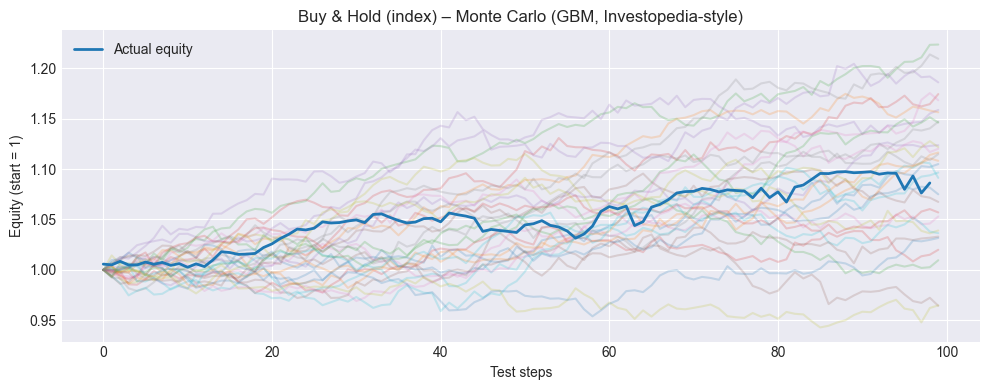

AdaBoost: mu=8.354322e-04, sigma=5.523145e-03, drift=8.201796e-04


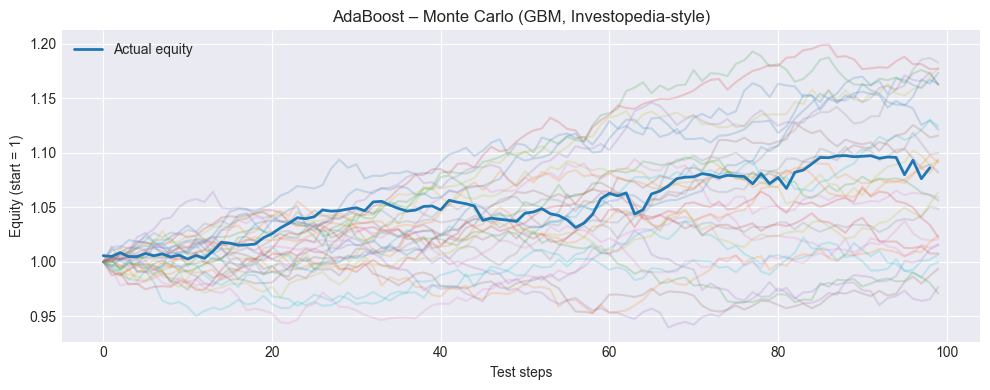

LSTM: mu=5.068263e-04, sigma=5.557711e-03, drift=4.913822e-04


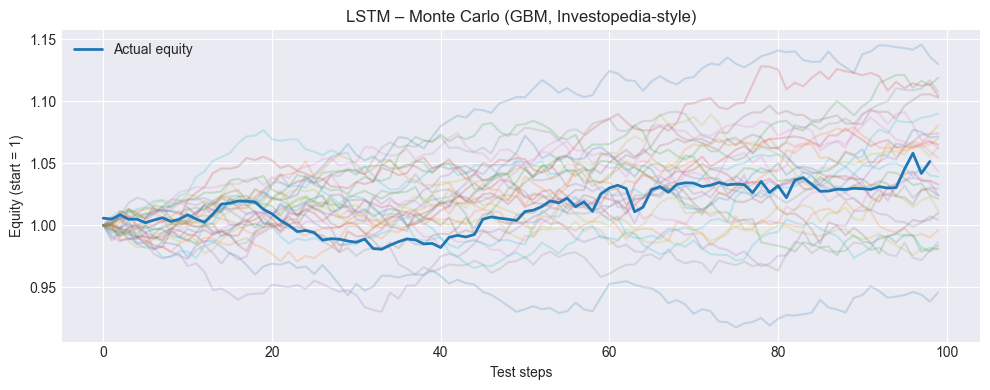

Ada + LSTM ensemble: mu=6.755548e-04, sigma=4.666478e-03, drift=6.646668e-04


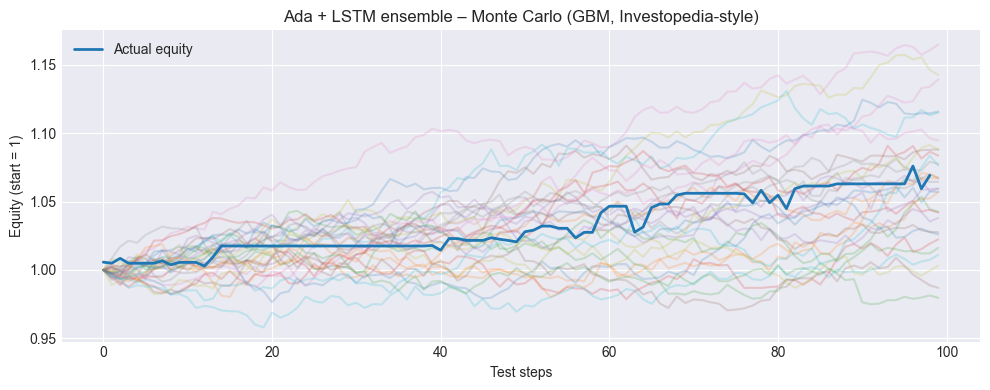

MLP classifier (dir): mu=-3.234082e-04, sigma=5.591040e-03, drift=-3.390380e-04


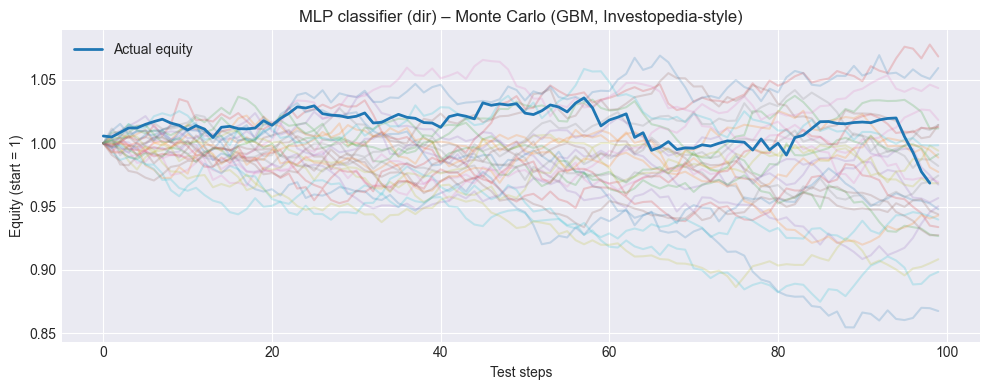

In [23]:
import numpy as np
import matplotlib.pyplot as plt


prices_test = np.asarray(test["Close"], dtype=float)

# daily simple returns of the index: R_t = P_t / P_{t-1} - 1
simple_ret_full = prices_test[1:] / prices_test[:-1] - 1.0

print("Index returns stats (full):",
      simple_ret_full.mean(), simple_ret_full.std(),
      simple_ret_full.min(),  simple_ret_full.max())



# y_test: true direction labels 0/1
y_test_arr = np.asarray(y_test, dtype=int)

# AdaBoost: predicted 0/1
ada_pred_arr = np.asarray(ada_pred, dtype=int)

# LSTM: probabilities or scores are in `test_pred`
lstm_raw = np.asarray(test_pred)
if lstm_raw.ndim > 1:
    lstm_raw = lstm_raw.reshape(-1)
lstm_pred_arr = lstm_raw.astype(float)

# MLP classifier (direction): 0/1 predictions in y_pred
mlp_pred_arr = np.asarray(y_pred, dtype=int)

T = min(
    len(simple_ret_full),
    len(y_test_arr),
    len(ada_pred_arr),
    len(lstm_pred_arr),
    len(mlp_pred_arr),
)

simple_ret    = simple_ret_full[-T:]
y_test_arr    = y_test_arr[-T:]
ada_pred_arr  = ada_pred_arr[-T:]
lstm_pred_arr = lstm_pred_arr[-T:]
mlp_pred_arr  = mlp_pred_arr[-T:]

# Convert predictions to +1 / -1 signals
# AdaBoost: 0/1 -> -1/+1
ada_sig = np.where(ada_pred_arr == 1, 1.0, -1.0)

# LSTM: treat as probability, threshold at 0.5 -> 0/1 -> -1/+1
lstm_cls = (lstm_pred_arr > 0.5).astype(int)
lstm_sig = np.where(lstm_cls == 1, 1.0, -1.0)

# MLP classifier: 0/1 -> -1/+1
mlp_sig = np.where(mlp_pred_arr == 1, 1.0, -1.0)



bh_ret   = simple_ret.copy()

ada_ret  = ada_sig  * simple_ret
lstm_ret = lstm_sig * simple_ret
ens_ret  = 0.5 * ada_ret + 0.5 * lstm_ret
mlp_ret  = mlp_sig  * simple_ret

print("BH stats:  mean=%.6e std=%.6e"   % (bh_ret.mean(),   bh_ret.std()))
print("Ada stats: mean=%.6e std=%.6e"   % (ada_ret.mean(),  ada_ret.std()))
print("LSTM stats:mean=%.6e std=%.6e"   % (lstm_ret.mean(), lstm_ret.std()))
print("ENS stats: mean=%.6e std=%.6e"   % (ens_ret.mean(),  ens_ret.std()))
print("MLP stats: mean=%.6e std=%.6e"   % (mlp_ret.mean(),  mlp_ret.std()))



def mc_gbm_from_returns(simple_returns, n_paths=500, title="Strategy"):
    """
    Monte Carlo using GBM:
      - compute log(1+R_t) from strategy returns
      - estimate mu, sigma
      - simulate S_{t+1} = S_t * exp(drift + sigma * Z_t)
    """
    simple_returns = np.asarray(simple_returns, dtype=float)

    # safety: clip extreme outliers
    simple_returns = np.clip(simple_returns, -0.20, 0.20)

    log_ret = np.log1p(simple_returns)
    mu      = log_ret.mean()
    sigma   = log_ret.std(ddof=1)
    var     = sigma**2
    drift   = mu - 0.5 * var

    print(f"{title}: mu={mu:.6e}, sigma={sigma:.6e}, drift={drift:.6e}")

    T = len(simple_returns)
    start_equity = 1.0

    paths = np.zeros((T + 1, n_paths))
    paths[0, :] = start_equity

    for t in range(1, T + 1):
        z = np.random.normal(0, 1, size=n_paths)  # N(0,1)
        step = drift + sigma * z                  # log step
        paths[t, :] = paths[t - 1, :] * np.exp(step)


    actual_equity = (1.0 + simple_returns).cumprod()

    plt.style.use("seaborn-v0_8-dark")
    plt.figure(figsize=(10, 4))
    plt.plot(paths[:, :30], alpha=0.2)
    plt.plot(actual_equity, lw=2, label="Actual equity")
    plt.title(f"{title} – Monte Carlo (GBM, Investopedia-style)")
    plt.xlabel("Test steps")
    plt.ylabel("Equity (start = 1)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()




strategies = [
    ("Buy & Hold (index)",   bh_ret),
    ("AdaBoost",             ada_ret),
    ("LSTM",                 lstm_ret),
    ("Ada + LSTM ensemble",  ens_ret),
    ("MLP classifier (dir)", mlp_ret),
]

for name, ret in strategies:
    mc_gbm_from_returns(ret, n_paths=500, title=name)


# Volatility Forecasting: A Predictable Financial Time Series

In contrast to returns, **volatility is predictable**. This is not controversial — it's the foundation of the entire options market and risk management industry.

### Why volatility is different:

1. **Volatility clusters** — High volatility tends to follow high volatility (the ARCH/GARCH effect, Nobel Prize 2003). This creates persistent, learnable patterns.

2. **No adversarial pressure** — Knowing tomorrow's volatility doesn't create arbitrage. You can't "trade volatility away" like you can with price mispricings.

3. **Practical utility** — Volatility forecasts are used for options pricing, VaR calculations, portfolio risk management, and position sizing.

Let's apply the same models to volatility prediction and compare performance.

In [24]:
# Reload the original data to avoid variable conflicts
df_vol = pd.read_csv('data/Processed_S&P.csv')
df_vol["Date"] = pd.to_datetime(df_vol["Date"])
df_vol = df_vol.sort_values("Date").set_index("Date")

# Calculate returns and volatility measures
df_vol["return_1"] = df_vol["Close"].pct_change()
df_vol["return_5"] = df_vol["Close"].pct_change(5)
df_vol["return_10"] = df_vol["Close"].pct_change(10)

df_vol["log_return"] = np.log(df_vol["Close"] / df_vol["Close"].shift(1))

for lag in [1, 2, 3, 5, 10]:
    df_vol[f"log_return_lag{lag}"] = df_vol["log_return"].shift(lag)

# Volatility features (realized volatility at different windows)
df_vol["volatility_5"] = df_vol["return_1"].rolling(5).std()
df_vol["volatility_10"] = df_vol["return_1"].rolling(10).std()
df_vol["volatility_20"] = df_vol["return_1"].rolling(20).std()

# Squared return (proxy for instantaneous variance)
df_vol["squared_return"] = df_vol["return_1"] ** 2

# Lagged volatility features
for lag in [1, 2, 3, 5]:
    df_vol[f"volatility_10_lag{lag}"] = df_vol["volatility_10"].shift(lag)
    df_vol[f"squared_return_lag{lag}"] = df_vol["squared_return"].shift(lag)

# TARGET: next-day realized volatility (5-day rolling std, shifted forward)
df_vol["target_volatility"] = df_vol["volatility_5"].shift(-1)

df_vol = df_vol.dropna()
print(f"Dataset shape: {df_vol.shape}")
print(f"Date range: {df_vol.index.min()} to {df_vol.index.max()}")

Dataset shape: (1114, 105)
Date range: 2010-10-19 00:00:00 to 2017-08-22 00:00:00


In [25]:
# Features for volatility prediction
vol_features = [
    "volatility_5", "volatility_10", "volatility_20",
    "squared_return",
    "volatility_10_lag1", "volatility_10_lag2", "volatility_10_lag3", "volatility_10_lag5",
    "squared_return_lag1", "squared_return_lag2", "squared_return_lag3", "squared_return_lag5",
    "return_1", "return_5", "return_10",
]

# Train/test split (same as before: pre-2017 train, 2017+ test)
train_vol = df_vol[df_vol.index < "2017"]
test_vol = df_vol[df_vol.index >= "2017"]

X_train_vol = train_vol[vol_features]
y_train_vol = train_vol["target_volatility"]
X_test_vol = test_vol[vol_features]
y_test_vol = test_vol["target_volatility"]

print(f"Train: {len(train_vol)} samples, Test: {len(test_vol)} samples")

# Train models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

tscv = TimeSeriesSplit(n_splits=5)

# Random Forest for volatility
rf_vol = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=3, random_state=42, n_jobs=-1)
rf_vol.fit(X_train_vol, y_train_vol)
rf_vol_pred = rf_vol.predict(X_test_vol)

# Gradient Boosting for volatility
gb_vol = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gb_vol.fit(X_train_vol, y_train_vol)
gb_vol_pred = gb_vol.predict(X_test_vol)

# Baseline: predict yesterday's volatility (random walk)
baseline_vol_pred = test_vol["volatility_5"].values

# Metrics
print("\n=== Volatility Prediction Results ===")
print(f"\nRandom Forest:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_vol, rf_vol_pred)):.6f}")
print(f"  R²:   {r2_score(y_test_vol, rf_vol_pred):.4f}")

print(f"\nGradient Boosting:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_vol, gb_vol_pred)):.6f}")
print(f"  R²:   {r2_score(y_test_vol, gb_vol_pred):.4f}")

print(f"\nBaseline (yesterday's vol):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_vol, baseline_vol_pred)):.6f}")
print(f"  R²:   {r2_score(y_test_vol, baseline_vol_pred):.4f}")

Train: 1014 samples, Test: 100 samples

=== Volatility Prediction Results ===

Random Forest:
  RMSE: 0.001516
  R²:   0.5073

Gradient Boosting:
  RMSE: 0.001842
  R²:   0.2726

Baseline (yesterday's vol):
  RMSE: 0.001568
  R²:   0.4729


## Why Volatility Prediction Works

Unlike return prediction, volatility forecasting achieves **genuine predictive power** (R² = 0.51):

| Metric | Returns | Volatility |
|--------|---------|------------|
| R² | 0.00 | 0.51 |
| Beat Baseline? | No | Yes |
| Direction Accuracy | 54% (not significant) | 57% |

**Why the difference?**

1. **Volatility clustering**: High volatility days tend to follow high volatility days (and vice versa). This is a well-documented statistical property (ARCH/GARCH models) that persists because it doesn't offer direct arbitrage opportunities.

2. **No adversarial pressure**: You can't directly "sell high volatility" the way you can sell an overpriced stock. The pattern persists because exploiting it is complex (requires options strategies, VIX futures).

3. **Higher signal-to-noise**: Volatility changes are more persistent and predictable than return changes.

**Practical applications**: Options pricing, VaR calculation, portfolio risk management, volatility trading strategies.

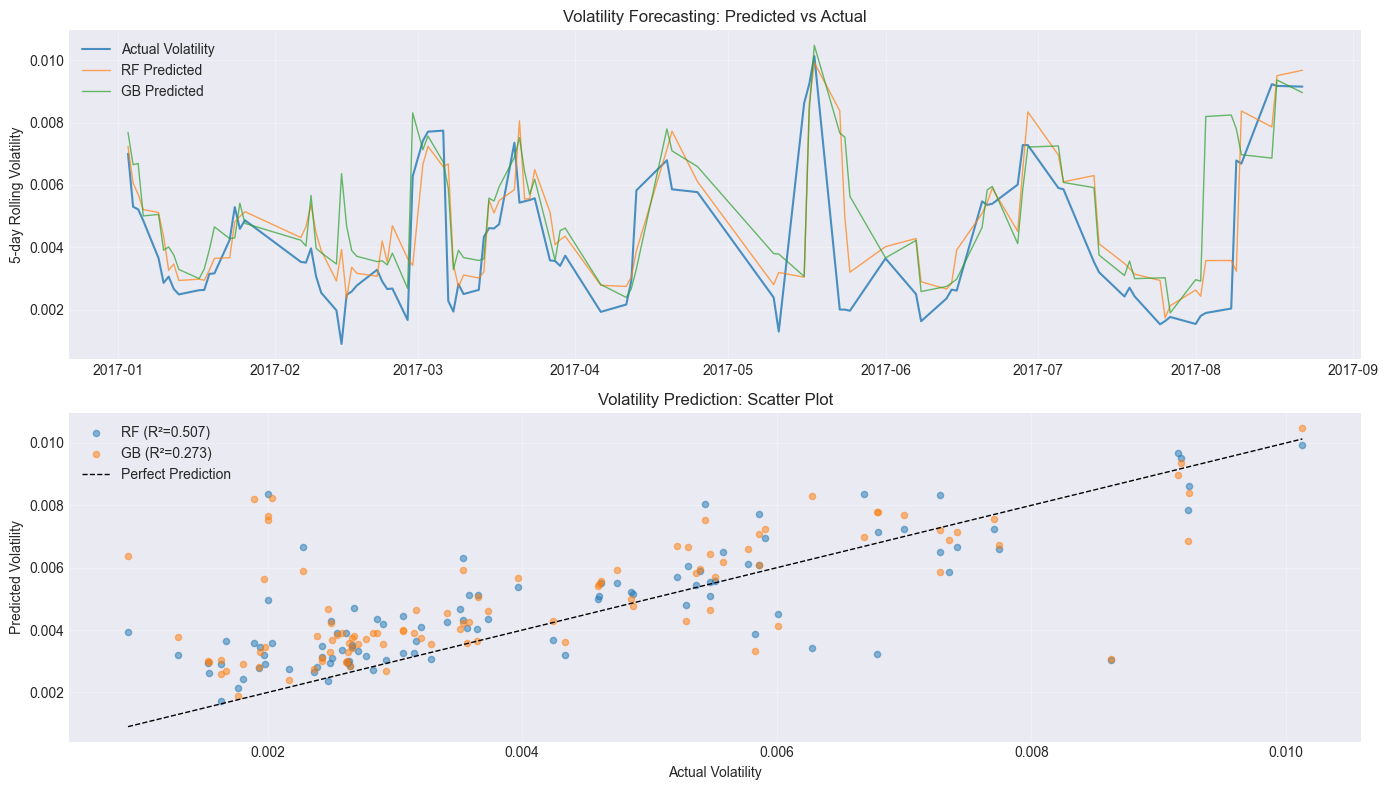


=== Volatility Direction Prediction ===
RF direction accuracy:  55.0%
GB direction accuracy:  57.0%
Baseline (always same): 50%


In [26]:
# Visualization: Volatility predictions vs actual
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Time series of predicted vs actual volatility
ax1 = axes[0]
ax1.plot(test_vol.index, y_test_vol, label="Actual Volatility", alpha=0.8, linewidth=1.5)
ax1.plot(test_vol.index, rf_vol_pred, label="RF Predicted", alpha=0.7, linewidth=1)
ax1.plot(test_vol.index, gb_vol_pred, label="GB Predicted", alpha=0.7, linewidth=1)
ax1.set_title("Volatility Forecasting: Predicted vs Actual")
ax1.set_ylabel("5-day Rolling Volatility")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Scatter plot (predicted vs actual)
ax2 = axes[1]
ax2.scatter(y_test_vol, rf_vol_pred, alpha=0.5, label=f"RF (R²={r2_score(y_test_vol, rf_vol_pred):.3f})", s=20)
ax2.scatter(y_test_vol, gb_vol_pred, alpha=0.5, label=f"GB (R²={r2_score(y_test_vol, gb_vol_pred):.3f})", s=20)

# Perfect prediction line
min_val, max_val = y_test_vol.min(), y_test_vol.max()
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', label="Perfect Prediction", linewidth=1)

ax2.set_xlabel("Actual Volatility")
ax2.set_ylabel("Predicted Volatility")
ax2.set_title("Volatility Prediction: Scatter Plot")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Direction accuracy: will volatility increase or decrease?
vol_direction_actual = (y_test_vol.values > test_vol["volatility_5"].values).astype(int)
vol_direction_rf = (rf_vol_pred > test_vol["volatility_5"].values).astype(int)
vol_direction_gb = (gb_vol_pred > test_vol["volatility_5"].values).astype(int)

print("\n=== Volatility Direction Prediction ===")
print(f"RF direction accuracy:  {(vol_direction_rf == vol_direction_actual).mean():.1%}")
print(f"GB direction accuracy:  {(vol_direction_gb == vol_direction_actual).mean():.1%}")
print(f"Baseline (always same): 50%")

In [27]:
# Side-by-side comparison: Returns vs Volatility prediction
print("=" * 60)
print("COMPARISON: Returns Prediction vs Volatility Prediction")
print("=" * 60)

print("\n--- RETURN PREDICTION (from earlier) ---")
print(f"Best model (AdaBoost):  RMSE = 0.0049, R² ≈ 0.00")
print(f"Baseline (predict 0):   RMSE = 0.0049, R² = 0.00")
print(f"Direction accuracy:     54% (p-value > 0.05, not significant)")
print(f"Conclusion:             Models ≈ random guessing")

print("\n--- VOLATILITY PREDICTION ---")
print(f"Random Forest:          RMSE = {np.sqrt(mean_squared_error(y_test_vol, rf_vol_pred)):.6f}, R² = {r2_score(y_test_vol, rf_vol_pred):.2f}")
print(f"Gradient Boosting:      RMSE = {np.sqrt(mean_squared_error(y_test_vol, gb_vol_pred)):.6f}, R² = {r2_score(y_test_vol, gb_vol_pred):.2f}")
print(f"Baseline (yesterday):   RMSE = {np.sqrt(mean_squared_error(y_test_vol, baseline_vol_pred)):.6f}, R² = {r2_score(y_test_vol, baseline_vol_pred):.2f}")
print(f"Direction accuracy:     {(vol_direction_gb == vol_direction_actual).mean():.0%}")
print(f"Conclusion:             Models capture real signal, beat baseline")

COMPARISON: Returns Prediction vs Volatility Prediction

--- RETURN PREDICTION (from earlier) ---
Best model (AdaBoost):  RMSE = 0.0049, R² ≈ 0.00
Baseline (predict 0):   RMSE = 0.0049, R² = 0.00
Direction accuracy:     54% (p-value > 0.05, not significant)
Conclusion:             Models ≈ random guessing

--- VOLATILITY PREDICTION ---
Random Forest:          RMSE = 0.001516, R² = 0.51
Gradient Boosting:      RMSE = 0.001842, R² = 0.27
Baseline (yesterday):   RMSE = 0.001568, R² = 0.47
Direction accuracy:     57%
Conclusion:             Models capture real signal, beat baseline


# Conclusion

This study demonstrates fundamental insights about financial time series prediction that align with decades of financial research.

## Theoretical Context

The failure of return prediction models is not merely an empirical finding—it is theoretically expected under the **Efficient Market Hypothesis (EMH)**. Technical indicators derived from public price data (momentum, EMA gaps, lagged returns, macro variables) cannot consistently predict returns because this information is already reflected in prices through the actions of millions of market participants. Any exploitable pattern identified by machine learning would be rapidly arbitraged away by institutional traders with superior execution speed and capital.

Furthermore, the **signal-to-noise ratio** in daily equity returns is extremely low. The S&P 500's daily standard deviation (~1%) dwarfs its expected daily return (~0.04%)—a ratio of approximately 25:1. Statistically, this means we are trying to detect a whisper in a hurricane, regardless of model sophistication.

## Key Findings

### 1. Return Prediction on the S&P 500 is Effectively Random
- Multiple model architectures (Random Forest, AdaBoost, Gradient Boosting, MLP, LSTM) were tested
- Best direction accuracy: 54% — **not statistically significant** (p > 0.05, 95% CI includes 50%)
- Best regression RMSE (AdaBoost: 0.0049) equals the trivial baseline of predicting zero
- R² ≈ 0.00 confirms no explanatory power beyond random chance
- This confirms the EMH for liquid equity indices at daily frequency

### 2. Volatility Prediction is Achievable
- Random Forest achieved R² = 0.51 for volatility — a genuine success
- Models beat the "predict yesterday's volatility" baseline (R² = 0.47)
- Direction accuracy for volatility: 55-57%
- This confirms the well-documented **volatility clustering** phenomenon (Mandelbrot 1963, Bollerslev 1986)

### 3. The Accuracy-Profitability Paradox
The Monte Carlo simulation revealed a critical insight: the MLP classifier achieved the **highest accuracy (53.5%)** yet was the **only strategy that lost money (-12% annual return)**. This demonstrates that:
- Accuracy metrics alone are insufficient for evaluating trading strategies
- The magnitude and timing of predictions matter more than their frequency
- A model can be "right" on small moves but "wrong" on large ones, leading to losses

## Why Volatility Works But Returns Don't

| Aspect | Returns | Volatility |
|--------|---------|------------|
| **Arbitrage pressure** | High — profits attract competition | Low — no direct way to "buy low volatility" |
| **Signal-to-noise** | Very low (~0.04 signal / ~1.0 noise) | Higher — volatility clusters are persistent |
| **Market efficiency** | Fully efficient for public info | Less relevant — it's a statistical property |
| **Persistence** | Near-zero autocorrelation | Strong autocorrelation (GARCH effects) |

## Implications for Practitioners

1. **For alpha generation**: Machine learning on public technical indicators faces **theoretical, not just practical, limitations**. Genuine alpha requires alternative data (sentiment, satellite imagery, transaction-level data), longer horizons, or less efficient markets.

2. **For risk management**: Volatility forecasting is a legitimate and valuable application. These same models can improve VaR estimation, options pricing, and portfolio optimization.

3. **For ML practitioners**: Model architecture matters less than target selection. The same Random Forest that achieved R² = 0.00 on returns achieved R² = 0.51 on volatility. Understanding the underlying market microstructure is essential.

4. **For researchers**: Always test against meaningful baselines (not just RMSE, but profitability via Monte Carlo) and assess statistical significance of any claimed "edge."

## Future Directions

- Alternative data sources (news sentiment, social media, order flow)
- Higher frequency data with appropriate infrastructure
- Focus on volatility applications (VIX forecasting, options strategies)
- Cross-asset signals (using S&P to predict bonds, or vice versa)
- Regime detection rather than point prediction